In [1]:
# =====================================================================
# CELL 0: ABSOLUTE TOP OF YOUR NOTEBOOK
# =====================================================================
import os

# FIX 1: Prevent Julia from overriding Python signal handles (Fixes the Segfault)
os.environ["PYTHON_JULIACALL_HANDLE_SIGNALS"] = "yes"

# FIX 2: Restrict Julia threads to keep it completely isolated from JAX/XLA thread pools
os.environ["JULIA_NUM_THREADS"] = "8"

# Force JAX backend configuration
os.environ["CBEAM_BACKEND"] = "jax"

import time
import warnings
import numpy as np
import jax
import jax.numpy as jnp

import cbeam
import matplotlib.pyplot as plt


Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython


In [2]:
# =====================================================================
# CELL 1: IMPORTS AND SYSTEM SETUP
# =====================================================================
# Same reconstructors as trainMLP.ipynb (jaxMLP + PySR), but trained on the
# *spectral* response instead of a single wavelength: each sample's feature
# vector is the per-fiber power at every native wavelength in
# [MINW, MAXW], unrolled into one vector of length WVL_SAMPLES * N_SIGNALS
# (17 x 19 = 323 here) instead of just N_SIGNALS (19).
#
# We get that response straight from MultiWavelengthPropagationPipeline
# .get_power_spectra() -- see CELL 2. That's already the per-fiber power at
# each native wavelength (cbeam's ChainPropagator.to_channel_basis() does the
# modal -> per-core channel conversion internally), so there's no need for
# the detector-plane round trip multi_wavelength.ipynb does (simulate a
# dispersed image with SpectralImageSimulator, then recover per-fiber flux
# from it with SpectralExtractor) just to get back to numbers we already had
# right after propagation. That also means this notebook never needs the
# core-calibration / subpixel-sampling step trainMLP.ipynb uses at a single
# wavelength (calibrate_subpixel_centers / map_evaluated_to_ideal_geometry /
# LinearNDInterpolator) -- to_channel_basis already returns fiber-ordered
# output, so ideal_grid_positions isn't needed either.

import time

import jax
import jax.numpy as jnp
from jax import random

from jaxMLP import (
    init_mlp_params, mlp_forward, huber_loss, update_step, get_batches
)

from batch_propagation_pipeline import get_simulation_parameters, create_random_aberration_configs
from multi_wvl_pipeline import MultiWavelengthPropagationPipeline

# --- CONSTANTS ---
N_SIGNALS = 19      # lantern output cores (nrings=3)
M_MODES = 5          # aberration modes to reconstruct

# Native wavelength grid -- same interval used in multi_wavelength.ipynb.
WVL_SAMPLES = 41
MINW, MAXW = 700.0, 900.0   # nm

PISTON_SPAN = 5000

DATASET_PATH = f"10Klantern_training_data_multiwl_{WVL_SAMPLES}.npz"
#DATASET_PATH = "lantern_training_data_multiwl_hard.npz"


Using JAX backend.
Using diffrax for ODE integration.


In [3]:
# =====================================================================
# CELL 2: MULTI-WAVELENGTH DATA GENERATION, PROCESSING & I/O
# =====================================================================
LOAD_DATA_FROM_DISK = True  # Set to True to skip simulation and load saved arrays

if LOAD_DATA_FROM_DISK and os.path.exists(DATASET_PATH):
    print(f"Loading dataset from {DATASET_PATH}...")
    data = np.load(DATASET_PATH)

    X_train, X_val = data['X_train'], data['X_val']
    Y_train, Y_val = data['Y_train'], data['Y_val']
    X_mean, X_std = data['X_mean'], data['X_std']
    Y_mean, Y_std = data['Y_mean'], data['Y_std']
    native_wl_nm = data['native_wl_nm']

    print(f"Loaded successfully! Train samples: {X_train.shape[0]}, Val samples: {X_val.shape[0]}, "
          f"feature length: {X_train.shape[1]} ({len(native_wl_nm)} wavelengths x {N_SIGNALS} fibers)")

else:
    print("Generating new multi-wavelength pipeline dataset...")
    base_params = get_simulation_parameters(nrings=3)

    print("\n" + "="*60)
    print("SIMULATION PARAMETERS")
    print("="*60)
    print(f"Wavelength range: {MINW}-{MAXW} nm ({WVL_SAMPLES} native samples)")
    print(f"Lantern length: {base_params['z_ex']} μm")
    print(f"Cladding radius: {base_params['rclad']} μm")
    print(f"Taper factor: {base_params['taper_factor']}")
    print(f"Available influence function: {base_params['ifunc_file']}")

    # 1. Pipeline Execution
    import specula

    print("Initializing SPECULA GPU...")
    specula.init(0)
    from specula.data_objects.ifunc import IFunc

    print("Loading influence function...")
    print(base_params["ifunc_file"])
    ifunc = IFunc.restore(base_params["ifunc_file"])

    native_wl_nm = np.linspace(MINW, MAXW, WVL_SAMPLES)

    # auto_mode_bookkeeping=True: away from the 800 nm hard-coded degenerate-
    # group / skipped-mode config, degen_groups/skipped_modes are derived
    # per wavelength from a compute_neffs() probe instead (see
    # multi_wvl/bookkeeping.py) -- needed here since native_wl_nm spans
    # 760-840 nm, not just 800.
    mwp = MultiWavelengthPropagationPipeline(
        base_params=base_params,
        ifunc=ifunc,
        native_wavelengths_nm=native_wl_nm,
        field_gen_on_gpu=False,
        field_gen_chunk_size=64,
        auto_mode_bookkeeping=True,
    )

    N_SAMPLES = 50000
    # coeff, _labels = create_sparse_aberration_configs_mono(n=N_SAMPLES, m=M_MODES, minv=-300, maxv=300)
    coeff, _labels = create_random_aberration_configs(n=N_SAMPLES, m=M_MODES, minv=-PISTON_SPAN, maxv=PISTON_SPAN)

    # power_spectra: (n_wavelengths, N_SAMPLES, n_fibers) real per-fiber flux,
    # already scaled by each field's input coupling efficiency so it stays
    # comparable across fields and across wavelengths (see
    # MultiWavelengthPropagationPipeline.get_power_spectra's docstring).
    # output_wavelengths_nm is left at its default (None): that returns
    # power at the native solve grid directly (wl_out == native_wl_nm) with
    # no interpolation, instead of interpolating onto a grid that's the same
    # as the native one anyway.
    power_spectra, wl_out = mwp.get_power_spectra(
        coeff,
        use_gpu=False,
        prop_chunk_size=32,
    )
    print(f"\npower_spectra shape: {power_spectra.shape}  "
          f"(n_wavelengths={power_spectra.shape[0]}, n_fields={power_spectra.shape[1]}, "
          f"n_fibers={power_spectra.shape[2]})")

    # 2. Unroll the wavelength axis into the feature vector.
    # power_spectra is (n_wl, n_fields, n_fibers); move fields to the front and
    # flatten (n_wl, n_fibers) -> one vector per field, wavelength-major (each
    # wavelength's N_SIGNALS fiber powers are contiguous). Order doesn't matter
    # to the MLP, only that it's applied consistently -- it is, since this is
    # the only place X_raw is built.
    X_raw = jnp.asarray(
        np.asarray(power_spectra).transpose(1, 0, 2).reshape(power_spectra.shape[1], -1)
    )
    Y_raw = jnp.array(coeff)

    print(f"Unrolled feature vector length: {X_raw.shape[1]} "
          f"({len(native_wl_nm)} wavelengths x {N_SIGNALS} fibers)")

    # 3. Scaling and Splitting
    X_mean, X_std = jnp.mean(X_raw, axis=0), jnp.std(X_raw, axis=0) + 1e-6
    Y_mean, Y_std = jnp.mean(Y_raw, axis=0), jnp.std(Y_raw, axis=0) + 1e-6
    X_scaled, Y_scaled = (X_raw - X_mean) / X_std, (Y_raw - Y_mean) / Y_std

    split_idx = int(0.8 * N_SAMPLES)
    X_train, X_val = X_scaled[:split_idx], X_scaled[split_idx:]
    Y_train, Y_val = Y_scaled[:split_idx], Y_scaled[split_idx:]

    # 4. Save Data for Next Time
    print(f"Saving dataset to {DATASET_PATH}...")
    np.savez(DATASET_PATH, X_train=X_train, Y_train=Y_train, X_val=X_val, Y_val=Y_val,
             X_mean=X_mean, X_std=X_std, Y_mean=Y_mean, Y_std=Y_std,
             native_wl_nm=native_wl_nm)
    print("Dataset generated and saved!")


Loading dataset from 10Klantern_training_data_multiwl_41.npz...
Loaded successfully! Train samples: 40000, Val samples: 10000, feature length: 779 (41 wavelengths x 19 fibers)


In [4]:
# =====================================================================
# CELL 3: MLP TRAINING EXECUTION
# =====================================================================
main_key = random.PRNGKey(42)
init_key, train_key = random.split(main_key, 2)

INPUT_DIM = X_train.shape[1]   # WVL_SAMPLES * N_SIGNALS (323 at the defaults above)

# Input grew ~17x (N_SIGNALS -> WVL_SAMPLES * N_SIGNALS), but the added
# information did not: adjacent native wavelengths see nearly the same
# aberration through a smoothly-varying dispersive response, so the extra
# columns are highly correlated, not independent. Widen the hidden layers
# (64 -> 128) rather than scale them by 17x.
layer_sizes = [INPUT_DIM, 256, 256, 256, 256, M_MODES]
params = init_mlp_params(layer_sizes, init_key)


In [5]:
EPOCHS = 40000
BATCH_SIZE = 128
LEARNING_RATE = 1e-2

print(f"\n--- Starting Wavefront Inversion Loop ({EPOCHS} Epochs) ---")
train_losses, val_losses = [], []

for epoch in range(1, EPOCHS + 1):
    start_epoch = time.time()
    train_key, batch_key = random.split(train_key)
    batches = get_batches(X_train, Y_train, BATCH_SIZE, batch_key)

    epoch_loss = 0.0
    for X_batch, Y_batch in batches:
        train_key, step_key = random.split(train_key)
        params, loss_val = update_step(params, X_batch, Y_batch, step_key, LEARNING_RATE)
        epoch_loss += loss_val
    epoch_loss /= len(batches)

    Y_val_pred = mlp_forward(params, X_val, deterministic=True)
    val_loss = huber_loss(Y_val, Y_val_pred)

    train_losses.append(epoch_loss)
    val_losses.append(val_loss)

    if epoch % 50 == 0 or epoch == 1:
        print(f"Epoch {epoch:03d} | Train Loss: {epoch_loss:.6f} | Val Loss: {val_loss:.6f} "
              f"| {time.time() - start_epoch:.3f} s/epoch")



--- Starting Wavefront Inversion Loop (40000 Epochs) ---
Epoch 001 | Train Loss: 0.476036 | Val Loss: 0.457123 | 17.304 s/epoch
Epoch 050 | Train Loss: 0.050053 | Val Loss: 0.053044 | 0.987 s/epoch
Epoch 100 | Train Loss: 0.029564 | Val Loss: 0.033304 | 1.067 s/epoch
Epoch 150 | Train Loss: 0.021680 | Val Loss: 0.025446 | 1.069 s/epoch
Epoch 200 | Train Loss: 0.017511 | Val Loss: 0.020927 | 1.193 s/epoch
Epoch 250 | Train Loss: 0.014794 | Val Loss: 0.017919 | 1.149 s/epoch
Epoch 300 | Train Loss: 0.012825 | Val Loss: 0.015755 | 1.198 s/epoch
Epoch 350 | Train Loss: 0.011371 | Val Loss: 0.014108 | 1.003 s/epoch
Epoch 400 | Train Loss: 0.010303 | Val Loss: 0.012809 | 1.028 s/epoch
Epoch 450 | Train Loss: 0.009348 | Val Loss: 0.011750 | 1.053 s/epoch
Epoch 500 | Train Loss: 0.008609 | Val Loss: 0.010870 | 0.957 s/epoch
Epoch 550 | Train Loss: 0.007980 | Val Loss: 0.010139 | 1.135 s/epoch
Epoch 600 | Train Loss: 0.007452 | Val Loss: 0.009505 | 1.084 s/epoch
Epoch 650 | Train Loss: 0.00699

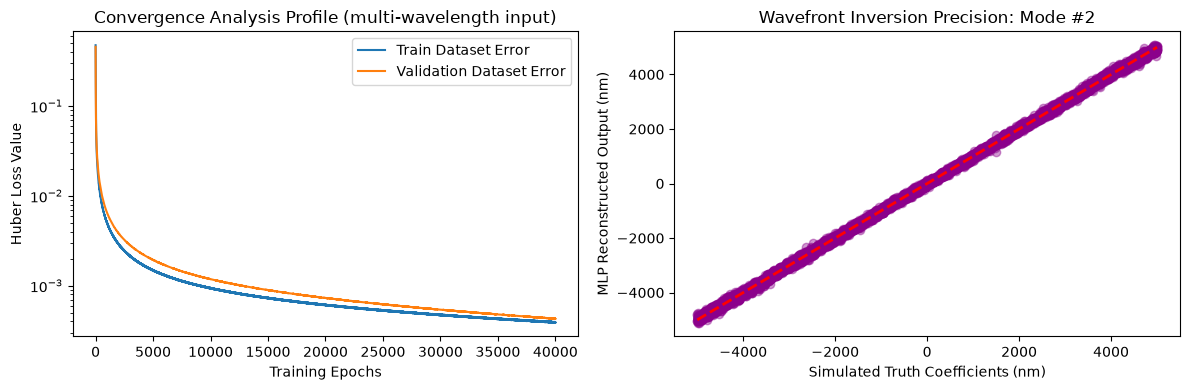

In [6]:
# =====================================================================
# CELL 5: DIAGNOSTIC PERFORMANCE ANALYSIS
# =====================================================================
Y_val_pred_scaled = mlp_forward(params, X_val, deterministic=True)
Y_val_pred_physical = (Y_val_pred_scaled * Y_std) + Y_mean
Y_val_true_physical = (Y_val * Y_std) + Y_mean

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Dataset Error')
plt.plot(val_losses, label='Validation Dataset Error')
plt.yscale('log')
plt.xlabel('Training Epochs')
plt.ylabel('Huber Loss Value')
plt.title('Convergence Analysis Profile (multi-wavelength input)')
plt.legend()

plt.subplot(1, 2, 2)
target_mode = 2
plt.scatter(Y_val_true_physical[:, target_mode], Y_val_pred_physical[:, target_mode], alpha=0.4, color='darkmagenta')
plt.plot([Y_val_true_physical.min(), Y_val_true_physical.max()], [Y_val_true_physical.min(), Y_val_true_physical.max()], 'r--', lw=2)
plt.xlabel('Simulated Truth Coefficients (nm)')
plt.ylabel('MLP Reconstructed Output (nm)')
plt.title(f'Wavefront Inversion Precision: Mode #{target_mode}')
plt.tight_layout()
plt.show()


In [5]:
# =====================================================================
# SHARED HELPERS  (copied from trainMLP.ipynb)
# =====================================================================
import os, pickle
import numpy as np
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import OrthogonalMatchingPursuit

Xtr = np.asarray(X_train, np.float64); Ytr = np.asarray(Y_train, np.float64)
Xva = np.asarray(X_val,   np.float64); Yva = np.asarray(Y_val,   np.float64)
sY  = np.asarray(Y_std)

RESULTS   = {}                       # model name -> per-mode validation RMSE (nm)
CACHE_DIR = "model_cache_multiwl"    # delete this folder after regenerating the dataset (CELL 2)

def cached(name, build):
    """Lazy fit/load.  If <CACHE_DIR>/<name>.pkl exists, unpickle and return it;
    otherwise call build(), pickle the result, and return it.  A cache read/write
    problem just triggers a refit -- it never raises."""
    os.makedirs(CACHE_DIR, exist_ok=True)
    path = os.path.join(CACHE_DIR, name.replace("/", "_").replace(" ", "_") + ".pkl")
    if os.path.exists(path):
        try:
            with open(path, "rb") as f:
                obj = pickle.load(f)
            print(f"[cache] loaded      {name}")
            return obj
        except Exception as e:
            print(f"[cache] load failed {name} ({e}); refitting")
    obj = build()
    try:
        with open(path, "wb") as f:
            pickle.dump(obj, f)
        print(f"[cache] fit + saved  {name}")
    except Exception as e:
        print(f"[cache] not saved    {name} ({e})")
    return obj

def val_rmse(P):
    """Per-mode validation RMSE (nm).  P: (n_val, M_MODES) predictions, standardized units."""
    return np.sqrt(np.mean(((np.asarray(P) - Yva) * sY) ** 2, axis=0))

def record(name, P):
    """Store per-mode val RMSE under `name`, print a one-line summary, return it."""
    RESULTS[name] = val_rmse(P)
    print(f"{name:16s}  mean {np.mean(RESULTS[name]):5.1f} nm   per-mode {np.round(RESULTS[name], 1)}")
    return RESULTS[name]

def poly_features(F_tr, F_va, degree):
    """Standardized degree-`degree` polynomial features.
    Returns (Ztr, Zva, scaler, PolynomialFeatures)."""
    pf  = PolynomialFeatures(degree, include_bias=False)
    Ptr = pf.fit_transform(F_tr)
    sc  = StandardScaler().fit(Ptr)
    return sc.transform(Ptr), sc.transform(pf.transform(F_va)), sc, pf

def omp_predict(Ztr, Zva, y_tr, K, screen=400):
    """OMP with a hard term budget K on a per-target |corr|-screened candidate pool.
    Returns (val_pred, fitted_omp, selected_global_indices)."""
    yc  = y_tr - y_tr.mean()
    sel = np.argsort(-np.abs(Ztr.T @ yc))[:min(screen, Ztr.shape[1])]
    omp = OrthogonalMatchingPursuit(n_nonzero_coefs=min(K, len(sel) - 1)).fit(Ztr[:, sel], y_tr)
    return omp.predict(Zva[:, sel]), omp, sel


In [6]:
# =====================================================================
# PER-WAVELENGTH ZERNIKE MODAL FEATURES
#   X is (n, WVL_SAMPLES*N_SIGNALS), wavelength-major (col = w*N_SIGNALS + fibre).
#   For each wavelength, project its N_SIGNALS fibre powers onto N_ZERN Noll
#   Zernikes -> (n, WVL_SAMPLES*N_ZERN) modal features.
#
#   Fibre ordering here is the NATIVE channel order: multi_wvl's
#   ChainPropagator.to_channel_basis() returns fibre-ordered output, so the
#   fibre positions come straight from get_simulation_parameters()["output_positions"]
#   -- no core_centers[ideal_perm] replay like in the single-wavelength notebook.
# =====================================================================
from math import factorial
from batch_propagation_pipeline import get_simulation_parameters

N_ZERN = 18          # Noll j = 1..N_ZERN  (small on purpose: deg-DEG_C poly over
                     #   WVL_SAMPLES*N_ZERN features must stay manageable)
DEG_C  = 3           # polynomial degree for the OMP features
FILL   = 0.8         # fibres occupy the inner FILL fraction of the unit disk
DROP_PISTON = False

WL_SUBSET = list(range(WVL_SAMPLES))     # wavelength indices to fit on, e.g. [4, 8, 12]
WL_SUBSET = np.asarray(WL_SUBSET, int)   # default = all WVL_SAMPLES

_p       = get_simulation_parameters(nrings=3)
core_pos = np.asarray(_p["output_positions"], float)          # hex_ring_positions(nrings, rclad/2.5)
assert len(core_pos) == N_SIGNALS, (len(core_pos), N_SIGNALS)

fxy = core_pos - core_pos.mean(0)
fxy = fxy / np.linalg.norm(fxy, axis=1).max() * FILL
rf, tf = np.linalg.norm(fxy, axis=1), np.arctan2(fxy[:, 1], fxy[:, 0])

def _nm(j):
    n = int(np.floor((-1 + np.sqrt(8 * (j - 1) + 1)) / 2))
    p = j - (n * (n + 1)) // 2 - 1
    m = 2 * ((p + 1) // 2) if n % 2 == 0 else 2 * (p // 2) + 1
    return n, (m if j % 2 == 0 else -m)

def _Rnm(n, m, r):
    m = abs(m); R = np.zeros_like(r)
    for k in range((n - m) // 2 + 1):
        R += ((-1) ** k * factorial(n - k) /
              (factorial(k) * factorial((n + m) // 2 - k) * factorial((n - m) // 2 - k))
              ) * r ** (n - 2 * k)
    return R

def _Z(j, r, t):
    n, m = _nm(j)
    nrm = np.sqrt(2 * (n + 1)) if m != 0 else np.sqrt(n + 1)
    return nrm * _Rnm(n, m, r) * (np.cos(m * t) if m >= 0 else np.sin(-m * t))

js  = np.arange(2 if DROP_PISTON else 1, N_ZERN + 1)
Bz  = np.stack([_Z(j, rf, tf) for j in js], axis=1)           # (N_SIGNALS, N_ZERN)
Bpi = np.linalg.pinv(Bz, rcond=1e-3)                          # (N_ZERN, N_SIGNALS)

zn = [f"w{w}Z{j}" for w in WL_SUBSET for j in js]     # len(WL_SUBSET) * N_ZERN names
print(f"Zernike basis {Bz.shape} (rank {np.linalg.matrix_rank(Bz)});  "
      f"wavelengths {list(WL_SUBSET)} = {native_wl_nm[WL_SUBSET].round(1)} nm;  "
      f"modal features = {len(WL_SUBSET)} wl x {len(js)} modes = {len(WL_SUBSET) * len(js)}")

def to_modal(Xstd):
    S = (np.asarray(Xstd) * np.asarray(X_std) + np.asarray(X_mean)   # de-standardise
         ).reshape(len(Xstd), WVL_SAMPLES, N_SIGNALS)                # (n, all wl, fibre)
    S = S[:, WL_SUBSET, :]                                           # keep chosen wavelengths
    return (S @ Bpi.T).reshape(len(Xstd), -1)                        # (n, len(WL_SUBSET)*N_ZERN)
    
# zn  = [f"w{w}Z{j}" for w in range(WVL_SAMPLES) for j in js]   # WVL_SAMPLES*N_ZERN names
# print(f"Zernike basis {Bz.shape} (rank {np.linalg.matrix_rank(Bz)});  "
#      f"modal features = {WVL_SAMPLES} wl x {len(js)} modes = {WVL_SAMPLES * len(js)}")

#def to_modal(Xstd):
#    """(n, WVL_SAMPLES*N_SIGNALS) standardized -> (n, WVL_SAMPLES*N_ZERN) modal coeffs."""
#    S = (np.asarray(Xstd) * np.asarray(X_std) + np.asarray(X_mean)      # de-standardise
#         ).reshape(len(Xstd), WVL_SAMPLES, N_SIGNALS)                   # (n, wl, fibre)
#    return (S @ Bpi.T).reshape(len(Xstd), -1)                           # (n, wl*N_ZERN)

C_tr_raw, C_va_raw = to_modal(X_train), to_modal(X_val)
Cmu, Csd = C_tr_raw.mean(0), C_tr_raw.std(0) + 1e-9
C_tr, C_va = (C_tr_raw - Cmu) / Csd, (C_va_raw - Cmu) / Csd
print(f"modal features: C_tr {C_tr.shape}, C_va {C_va.shape}")


Zernike basis (19, 18) (rank 18);  wavelengths [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29), np.int64(30), np.int64(31), np.int64(32), np.int64(33), np.int64(34), np.int64(35), np.int64(36), np.int64(37), np.int64(38), np.int64(39), np.int64(40)] = [700. 705. 710. 715. 720. 725. 730. 735. 740. 745. 750. 755. 760. 765.
 770. 775. 780. 785. 790. 795. 800. 805. 810. 815. 820. 825. 830. 835.
 840. 845. 850. 855. 860. 865. 870. 875. 880. 885. 890. 895. 900.] nm;  modal features = 41 wl x 18 modes = 738
modal features: C_tr (40000, 738), C_va (10000, 738)


In [ ]:
# =====================================================================
# Compact model: OMP on degree-DEG_C polynomial of the per-wavelength Zernike
# modal features, explicit term budget K.
#   - exploratory sweep over Ks  (RUN_SWEEP = False to skip)
#   - budgets in STORE_K are fit-or-loaded (cached) for the comparison plot
# =====================================================================
import warnings
warnings.filterwarnings("ignore", message="Orthogonal matching pursuit ended prematurely")

# --- wavelength subsampling -------------------------------------------
# The degree-DEG_C expansion is cubic in the number of modal features, and
# C_tr is (n, len(WL_SUBSET)*N_ZERN) with all 41 wavelengths.  The 41 native
# samples across 700-900 nm are a smooth, highly redundant sampling of the
# lantern response, so fit on every WL_STRIDE-th one.
WL_STRIDE = 5
WL_KEEP   = np.arange(0, len(WL_SUBSET), WL_STRIDE)    # indices INTO WL_SUBSET
WL_FIT    = np.asarray(WL_SUBSET)[WL_KEEP]             # native wavelength indices fitted

def _keep_wl(C):
    """(n, len(WL_SUBSET)*N_ZERN) -> (n, len(WL_KEEP)*N_ZERN).  C is
    wavelength-major: to_modal() builds (n, wl, N_ZERN) and flattens it."""
    return C.reshape(len(C), len(WL_SUBSET), N_ZERN)[:, WL_KEEP].reshape(len(C), -1)

zn_fit = [f"w{w}Z{j}" for w in WL_FIT for j in js]      # names for the kept columns

# --- row subsampling ---------------------------------------------------
# The polynomial matrices are (n_rows, n_poly_terms) and n_poly_terms is fixed
# by the feature side, so the only remaining lever on memory is n_rows.  Fit
# on a random N_FIT-row subset instead of all 40000; N_VAL does the same for
# the validation matrix (set either to None to keep every row).
# NOTE the fit rows must be drawn from C_tr and Ytr with the SAME indices.
# N_VAL is a last-resort lever only: cell 10 compares this model against
# linear/kNN/MLP via record(), which scores every model on the FULL Yva, so a
# validation subset here would make that comparison apples-to-oranges.
N_FIT, N_VAL, FIT_SEED = 10000, None, 0
_rng = np.random.default_rng(FIT_SEED)

def _rows(n_have, n_want):
    if n_want is None or n_want >= n_have:
        return np.arange(n_have)
    return np.sort(_rng.choice(n_have, size=n_want, replace=False))

fit_idx, val_idx = _rows(len(C_tr), N_FIT), _rows(len(C_va), N_VAL)
C_fit, Y_fit = _keep_wl(C_tr)[fit_idx], Ytr[fit_idx]   # same rows in both
C_val, Y_val_ = _keep_wl(C_va)[val_idx], Yva[val_idx]

# --- term budgets ------------------------------------------------------
# omp_predict() screens to SCREEN candidates, then OMP takes
# n_nonzero_coefs = min(K, len(sel)-1).  A budget that reaches SCREEN selects
# nearly every candidate, so K stops binding and the sweep is uninformative.
# K must also stay well under the row count or the fit is underdetermined --
# hence the cap against both.
SCREEN    = 6000
K_CAP     = min(SCREEN // 4, len(C_fit) // 8)
Ks        = [k for k in (200, 500, 1000, 1500) if k <= K_CAP]
STORE_K   = list(Ks)
RUN_SWEEP = True
assert Ks, f"K_CAP={K_CAP} too small for any budget; raise N_FIT or SCREEN"

if N_VAL is not None:
    warnings.warn("N_VAL set -- cell 10's comparison plot scores the other "
                  "models on the full Yva and will not be comparable.")

Ztr, Zva, sc, pf = poly_features(C_fit, C_val, DEG_C)
pn = pf.get_feature_names_out(zn_fit)
print(f"fitting {len(WL_FIT)}/{len(WL_SUBSET)} wavelengths x {N_ZERN} Zernikes "
      f"= {C_fit.shape[1]} modal features")
print(f"rows: fit {len(C_fit)}/{len(C_tr)}, val {len(C_val)}/{len(C_va)}")
print(f"zern deg{DEG_C}: {Ztr.shape[1]} polynomial terms  ->  "
      f"Ztr {Ztr.nbytes / 2**30:.1f} GiB + Zva {Zva.nbytes / 2**30:.1f} GiB")
print(f"screening to {SCREEN}; budgets {Ks} (cap {K_CAP})\n")

def fit_mode(k, K):
    """OMP for mode k with term budget K.  Returns (omp, sel, val_rmse_nm, val_pred)."""
    pred, omp, sel = omp_predict(Ztr, Zva, Y_fit[:, k], K, screen=SCREEN)
    r = float(np.sqrt(np.mean(((pred - Y_val_[:, k]) * sY[k]) ** 2)))
    return omp, sel, r, pred

if RUN_SWEEP:
    for K in Ks:
        out = [fit_mode(k, K) for k in range(M_MODES)]
        nt  = [int(np.sum(o[0].coef_ != 0)) for o in out]
        rs  = [o[2] for o in out]
        print(f"K={K:4d}:  terms {nt}   mean RMSE {np.mean(rs):5.1f} nm")

In [ ]:
for K in STORE_K:
    # WL_FIT, not WL_SUBSET: the tag must name the wavelengths actually fitted
    # in the cell above, or changing WL_STRIDE silently reloads a stale cache.
    TAG = f"z{N_ZERN}d{DEG_C}n{len(C_fit)}w{'-'.join(map(str, WL_FIT))}"
    fits = cached(f"zern-omp-{TAG}-K{K}",
                  lambda K=K: [omp_predict(Ztr, Zva, Y_fit[:, k], K, screen=SCREEN)[1:]
                               for k in range(M_MODES)])          # [(omp, sel), ...]
    P = np.stack([o.predict(Zva[:, s]) for (o, s) in fits], axis=1)
    record(f"zern-omp-K{K}", P)
    

In [ ]:
# =====================================================================
# COMPARISON: per-mode validation RMSE  --  OMP (per-wavelength Zernike) vs MLP
# =====================================================================
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import Ridge

record("linear", cached("linear", lambda: Ridge(1.0).fit(Xtr, Ytr)).predict(Xva))
record("kNN",    cached("kNN", lambda: KNeighborsRegressor(5, weights="distance").fit(Xtr, Ytr)).predict(Xva))
record("MLP",    np.asarray(mlp_forward(params, jnp.asarray(Xva), deterministic=True)))

order  = ["linear", f"zern-omp-K{max(STORE_K)}", "MLP", "kNN"]
labels = [m for m in order if m in RESULTS]

print("\nmean val RMSE (nm):")
for m in labels:
    print(f"  {m:16s} {np.mean(RESULTS[m]):6.1f}   per-mode {np.round(RESULTS[m], 1)}")

x = np.arange(M_MODES); w = 0.8 / max(len(labels), 1)
plt.figure(figsize=(11, 5))
for i, m in enumerate(labels):
    plt.bar(x + (i - len(labels) / 2) * w + w / 2, RESULTS[m], w, label=m)
if "kNN" in RESULTS:
    plt.axhline(np.mean(RESULTS["kNN"]), color="k", ls="--", lw=1)
plt.xlabel("wavefront mode"); plt.ylabel("validation RMSE (nm)")
plt.xticks(x); plt.legend(fontsize=9)
plt.title("Multi-wavelength: OMP on per-wavelength Zernike features vs MLP")
plt.grid(True, axis="y", ls=":", alpha=0.5)
plt.tight_layout(); plt.show()
